# Decission tree

# 1 Importar librerias

In [15]:
import os
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split

# 2. Abrir csv

In [16]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/diabetes.csv")
# Fijar el id como indice
pd.set_option('display.max_columns', None)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# 3. Cribado manual

## 3.1 Columnas con valores únicos

In [17]:
unicos = df.nunique()
df[unicos[unicos == 1].index]

""
0
1
2
3
4
...
763
764
765
766


## 3.2 Visualizar valores duplicados

### Filas

In [18]:
filas_dupli = df.duplicated()
df[filas_dupli]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### Columnas

In [19]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 3.3 Datos faltantes

In [20]:
missing=df.isna().mean()*100
missing[missing>0]

Series([], dtype: float64)

In [21]:
fila_datos_faltantes = df.isna().any(axis=1).sum() # any sirve para ver CUALQUIER dato faltante
fila_datos_faltantes[fila_datos_faltantes>0]

array([], dtype=int64)

<Axes: >

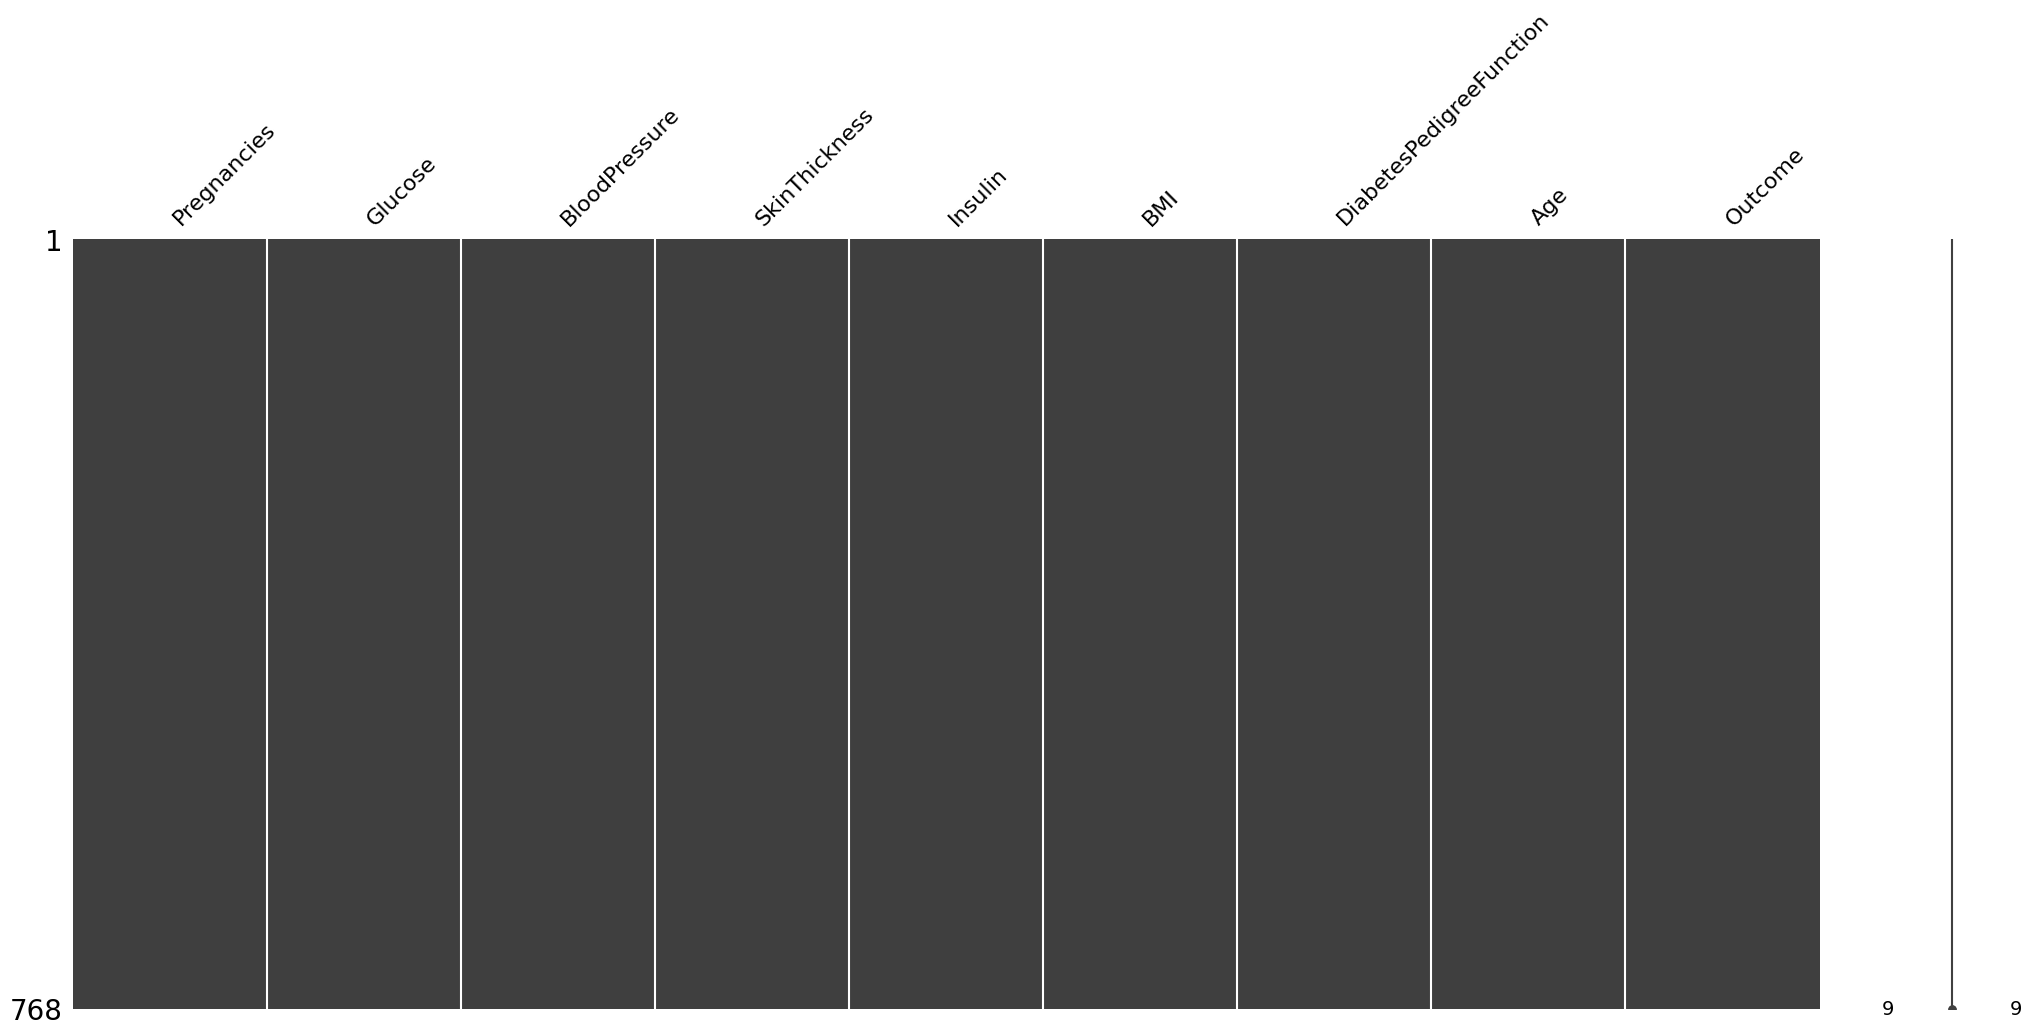

In [22]:
msno.matrix(df)

## 4 División train/test

In [23]:
X = df.drop('Outcome',axis=1) 
y = df['Outcome']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46


# 5 Outiliers

In [26]:
columns=["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
X_train[columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.742671,3.313264,0.000,1.0000,3.0000,6.00000,17.00
Glucose,614.0,120.855049,32.035057,0.000,100.0000,117.0000,139.00000,199.00
BloodPressure,614.0,69.415309,18.512599,0.000,64.0000,72.0000,80.00000,122.00
SkinThickness,614.0,20.399023,15.433974,0.000,0.0000,23.0000,32.00000,63.00
Insulin,614.0,81.438111,116.234835,0.000,0.0000,42.5000,129.75000,846.00
BMI,614.0,31.983388,7.740625,0.000,27.1000,32.0000,36.37500,67.10
DiabetesPedigreeFunction,614.0,0.469168,0.336847,0.078,0.2415,0.3725,0.61375,2.42
Age,614.0,32.907166,11.503437,21.000,24.0000,29.0000,40.00000,81.00


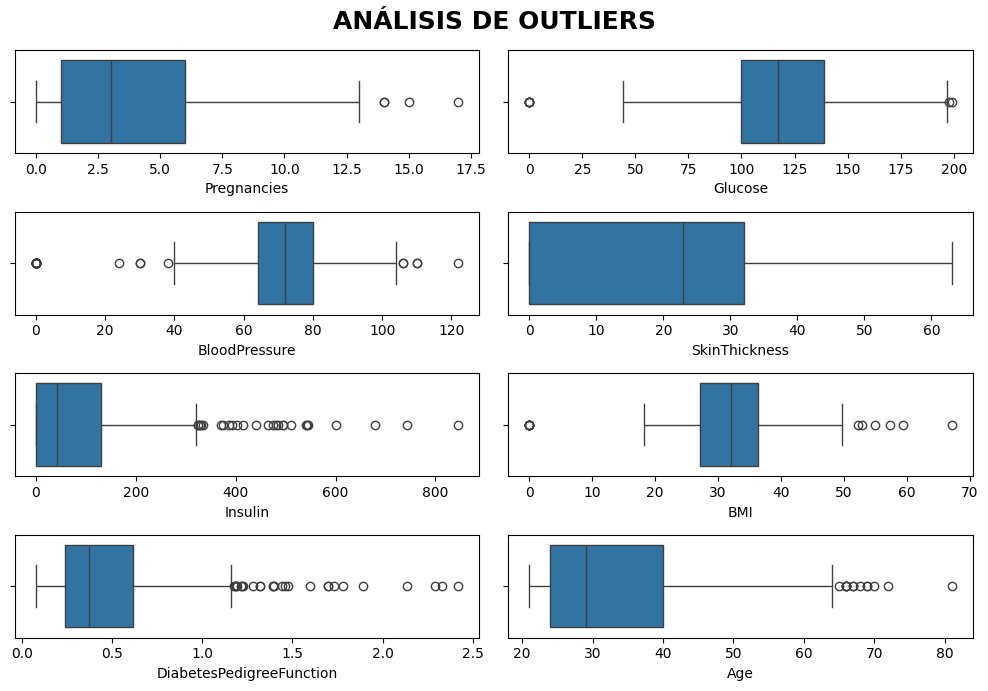

In [27]:
fig, axis = plt.subplots(4, 2, figsize = (10, 7))

# Crear una figura múltiple con histogramas y diagramas de caja
sns.boxplot(ax = axis[0, 0], data = X_train, x = "Pregnancies")
sns.boxplot(ax = axis[0, 1],data = X_train, x = "Glucose")
sns.boxplot(ax = axis[1, 0],data = X_train, x = "BloodPressure")
sns.boxplot(ax = axis[1, 1],data = X_train, x = "SkinThickness")
sns.boxplot(ax = axis[2, 0],data = X_train, x = "Insulin")
sns.boxplot(ax = axis[2, 1],data = X_train, x = "BMI")
sns.boxplot(ax = axis[3, 0],data = X_train, x = "DiabetesPedigreeFunction")
sns.boxplot(ax = axis[3, 1],data = X_train, x = "Age")
fig.suptitle("Análisis de Outliers".upper(), size=18, fontweight="bold")
# Ajustar el layout
plt.tight_layout()
# Mostrar el plot
plt.show()

## 6. Selección de características

NameError: name 'joblib' is not defined